<a href="https://colab.research.google.com/github/ManoloArriola/black-swan-analysis/blob/main/The_Black_Swan_in_Consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Black Swan in Consumption**



# Black Swan Detection: From Global Markets to Regional Context
## Project Overview
This project explores **Nassim Taleb's Black Swan Theory** through data analysis. While I initially analyze global giants like **Toyota** and **Tesla**, the core objective is to build a robust framework that can be applied to any market, including emerging economies like **Guatemala**.

By identifying outliers (anomalies) in financial data, we can distinguish between predictable market behavior and extreme events that require urgent management decisions.

In [1]:
# Install the financial data library
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1. Download data
ticker = "TM"
data_real = yf.download(ticker, period="1y", interval="1d")

# 2. FIX: Flatten the data (Aplanar los títulos de las columnas)
# Esto elimina las capas extra que causan el ValueError
df_toyota = data_real[['Close']].copy()
df_toyota.columns = ['Close']
df_toyota = df_toyota.reset_index()

# 3. Calculate statistics safely
# Usamos .values[0] si el resultado es una serie, para obtener solo el número
mean_toyota = df_toyota['Close'].mean()
std_toyota = df_toyota['Close'].std()

upper_tm = mean_toyota + (3 * std_toyota)
lower_tm = mean_toyota - (3 * std_toyota)

# 4. Filter Black Swans
black_swans_tm = df_toyota[(df_toyota['Close'] > upper_tm) | (df_toyota['Close'] < lower_tm)]

print(f"Mean Price for {ticker}: {mean_toyota:.2f}")

/tmp/ipykernel_7450/906327255.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_real = yf.download(ticker, period="1y", interval="1d")
[*********************100%***********************]  1 of 1 completed

Mean Price for TM: 201.81


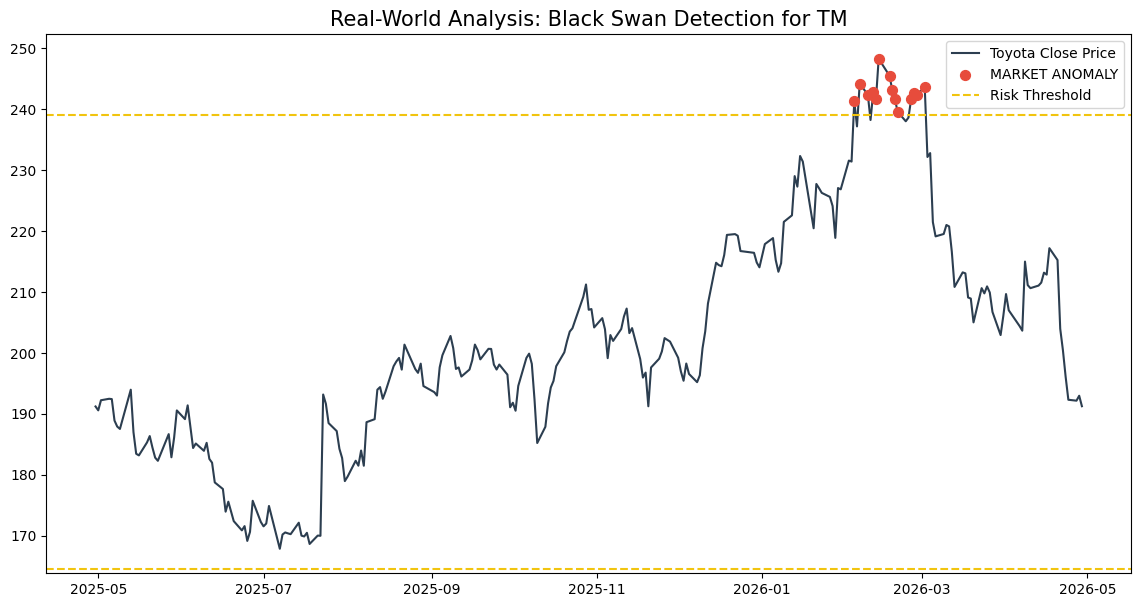

In [3]:
# 1. Calculate statistics
mean_toyota = df_toyota['Close'].mean()
std_toyota = df_toyota['Close'].std()

# 2. Define the 3-Sigma Thresholds
upper_tm = mean_toyota + (2 * std_toyota)
lower_tm = mean_toyota - (2 * std_toyota)

# 3. Identify Real Black Swans
black_swans_tm = df_toyota[(df_toyota['Close'] > upper_tm) | (df_toyota['Close'] < lower_tm)]

# 4. Visualization
plt.figure(figsize=(14, 7))
plt.plot(df_toyota['Date'], df_toyota['Close'], color='#2c3e50', label='Toyota Close Price')

# Highlight detected anomalies
plt.scatter(black_swans_tm['Date'], black_swans_tm['Close'], color='#e74c3c', s=50, label='MARKET ANOMALY', zorder=5)

# Threshold lines
plt.axhline(y=upper_tm, color='#f1c40f', linestyle='--', label='Risk Threshold')
plt.axhline(y=lower_tm, color='#f1c40f', linestyle='--')

plt.title(f'Real-World Analysis: Black Swan Detection for {ticker}', fontsize=15)
plt.legend()
plt.savefig('black_swan_analysis_toyota.png', dpi=300)
plt.show()

Let's add a comparision with another compani, Tesla in this case.


/tmp/ipykernel_7450/4214291772.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_comp = yf.download(tickers, period="1y")['Close']
[*********************100%***********************]  2 of 2 completed


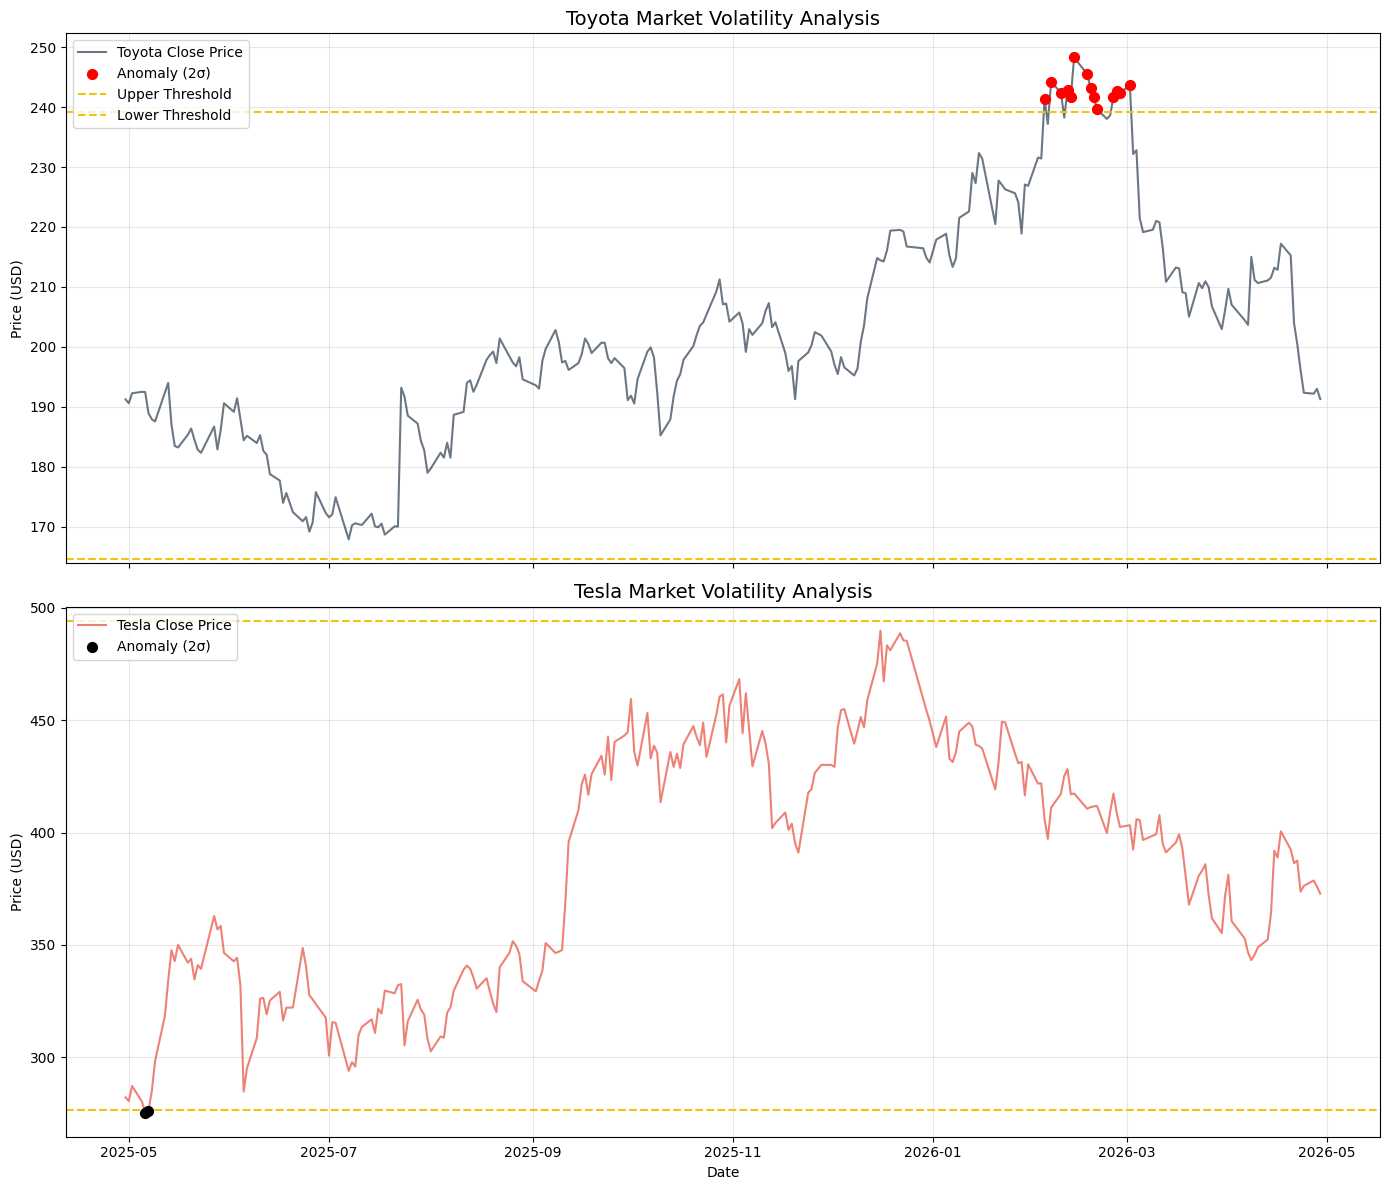

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Toyota Anomalies (2σ): 14
Tesla Anomalies (2σ): 2


In [4]:
# STEP 5 (REVISED): Comparative Analysis with Threshold Lines
tickers = ["TM", "TSLA"]
data_comp = yf.download(tickers, period="1y")['Close']
data_comp = data_comp.dropna()

def get_stats_and_swans(series):
    m = series.mean()
    s = series.std()
    upper = m + (2 * s) # High Sensitivity Threshold
    lower = m - (2 * s)
    swans = series[(series > upper) | (series < lower)]
    return m, upper, lower, swans

# Visualization Setup
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# --- Plot Toyota (TM) ---
# 1. Get stats
tm_mean, tm_upper, tm_lower, tm_swans = get_stats_and_swans(data_comp['TM'])

# 2. Draw Plot
ax1.plot(data_comp.index, data_comp['TM'], color='#2c3e50', label='Toyota Close Price', alpha=0.7)
ax1.scatter(tm_swans.index, tm_swans, color='red', s=50, label='Anomaly (2σ)', zorder=5)

# 3. Add Threshold Lines (The yellow lines you missed!)
ax1.axhline(y=tm_upper, color='#f1c40f', linestyle='--', label='Upper Threshold')
ax1.axhline(y=tm_lower, color='#f1c40f', linestyle='--', label='Lower Threshold')

ax1.set_title('Toyota Market Volatility Analysis', fontsize=14)
ax1.set_ylabel('Price (USD)')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)


# --- Plot Tesla (TSLA) ---
# 1. Get stats
tsla_mean, tsla_upper, tsla_lower, tsla_swans = get_stats_and_swans(data_comp['TSLA'])

# 2. Draw Plot
ax2.plot(data_comp.index, data_comp['TSLA'], color='#e74c3c', label='Tesla Close Price', alpha=0.7)
ax2.scatter(tsla_swans.index, tsla_swans, color='black', s=50, label='Anomaly (2σ)', zorder=5)

# 3. Add Threshold Lines
ax2.axhline(y=tsla_upper, color='#f1c40f', linestyle='--')
ax2.axhline(y=tsla_lower, color='#f1c40f', linestyle='--')

ax2.set_title('Tesla Market Volatility Analysis', fontsize=14)
ax2.set_ylabel('Price (USD)')
ax2.set_xlabel('Date')
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()

# Save and Download with correct order
plt.savefig('market_comparison_final.png', dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('market_comparison_final.png')

print(f"Toyota Anomalies (2σ): {len(tm_swans)}")
print(f"Tesla Anomalies (2σ): {len(tsla_swans)}")


## Strategic Conclusion
After analyzing both simulated and real-world data (Toyota vs. Tesla), we conclude that:
1. **Volatility is not Risk:** A volatile asset like Tesla generates more "alerts," but a Black Swan is only critical when it threatens the structural survival of the operation.
2. **Context Matters:** Applying this model to regional data, such as the **Guatemalan Quetzal (GTQ)** or agricultural commodities, allows for better macro-economic risk management.
3. **Decision Framework:** Management should not overreact to every outlier, but rather use the **3-Sigma threshold** to identify which events truly break the historical trend.

In the Guatemalan context, seasonality plays a critical role. While Coffee and Sugar are both vital, their harvest periods (Zafra vs. Coffee picking) differ. This project aims to identify if 'Black Swan' climatic events during specific months hit one commodity harder than the other, providing a localized risk assessment tool.

/tmp/ipykernel_7450/4077338705.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_comm = yf.download(commodities, period="2y")['Close']
[*********************100%***********************]  2 of 2 completed


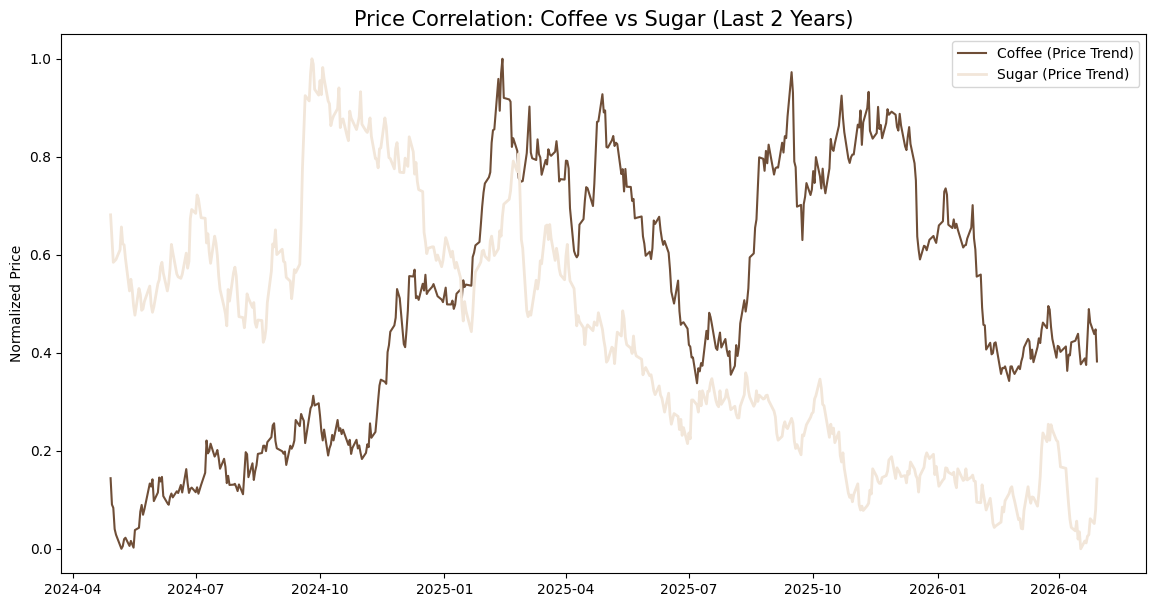

Correlation between coffe and sugar is: -0.38


In [5]:
# STEP 6: Agricultural Commodities Analysis (Coffee vs Sugar)
# KC=F is Coffee / SB=F is Sugar
commodities = ["KC=F", "SB=F"]
data_comm = yf.download(commodities, period="2y")['Close']
data_comm = data_comm.dropna()

# Rename
data_comm.columns = ['Coffee', 'Sugar']

# We normalized the data (so that we could compare them on the same scale of 0 to 1).
data_norm = (data_comm - data_comm.min()) / (data_comm.max() - data_comm.min())

# Graph
plt.figure(figsize=(14, 7))
plt.plot(data_norm.index, data_norm['Coffee'], label='Coffee (Price Trend)', color='#6f4e37')
plt.plot(data_norm.index, data_norm['Sugar'], label='Sugar (Price Trend)', color='#f2e6d9', linewidth=2)

plt.title('Price Correlation: Coffee vs Sugar (Last 2 Years)', fontsize=15)
plt.ylabel('Normalized Price')
plt.legend()
plt.show()

# Technical correlation calculation
correlation = data_comm['Coffee'].corr(data_comm['Sugar'])
print(f"Correlation between coffe and sugar is: {correlation:.2f}")

/tmp/ipykernel_7450/3898459613.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_comm = yf.download(commodities, period="2y")['Close']
[*********************100%***********************]  2 of 2 completed


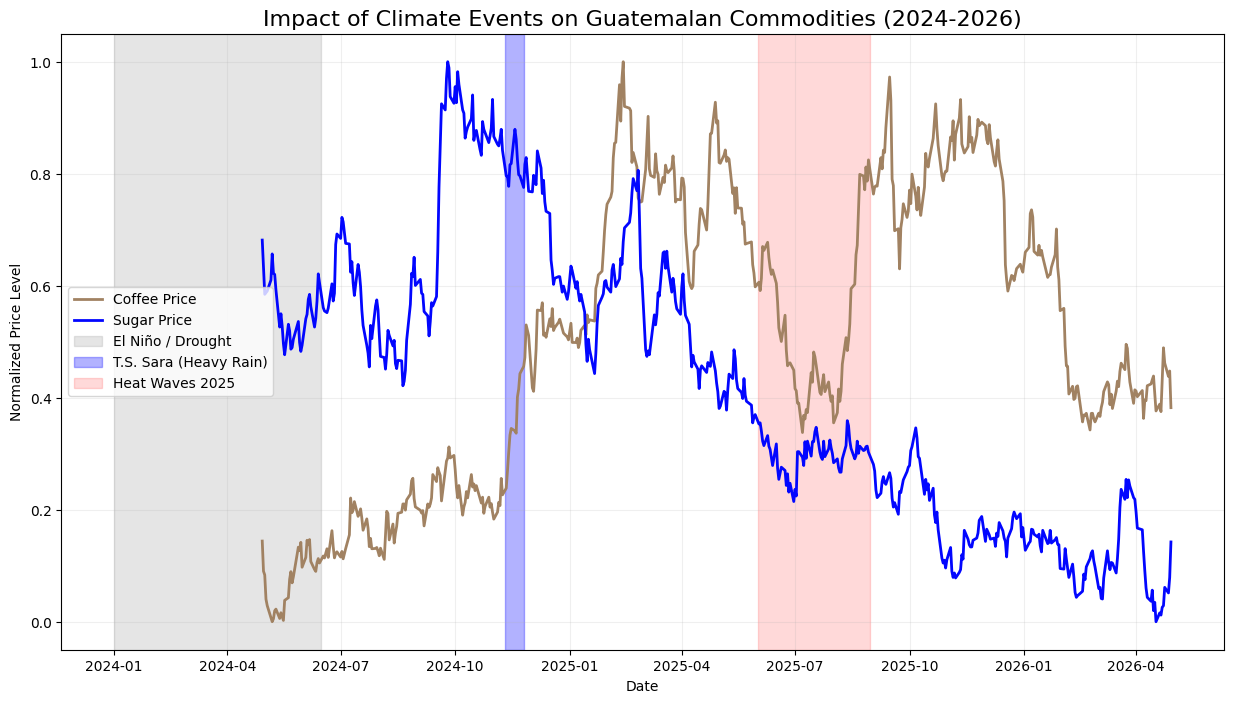

In [6]:
# STEP 7: Climate Events vs Commodity Prices
import matplotlib.dates as mdates

# 1. Download Data
commodities = ["KC=F", "SB=F"] # Coffee and Sugar
data_comm = yf.download(commodities, period="2y")['Close']
data_comm = data_comm.dropna()

# 2. Normalize to compare in the same scale (0 to 1)
data_norm = (data_comm - data_comm.min()) / (data_comm.max() - data_comm.min())

# 3. Plotting
plt.figure(figsize=(15, 8))
plt.plot(data_norm.index, data_norm['KC=F'], label='Coffee Price', color='#a18262', linewidth=2)
plt.plot(data_norm.index, data_norm['SB=F'], label='Sugar Price', color='#0206ff', linewidth=2)

# --- SHADING CLIMATE EVENTS ---

# Event 1: El Niño Drought (Jan - Jun 2024)
plt.axvspan('2024-01-01', '2024-06-15', color='gray', alpha=0.2, label='El Niño / Drought')

# Event 2: Tropical Storm Sara (Nov 2024)
plt.axvspan('2024-11-10', '2024-11-25', color='blue', alpha=0.3, label='T.S. Sara (Heavy Rain)')

# Event 3: 2025 Heat Waves / Canícula (Jun - Aug 2025)
plt.axvspan('2025-06-01', '2025-08-30', color='red', alpha=0.15, label='Heat Waves 2025')

# Formatting
plt.title('Impact of Climate Events on Guatemalan Commodities (2024-2026)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Normalized Price Level')
plt.legend(loc='center left')
plt.grid(alpha=0.2)
plt.show()